In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1304s 8us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [4]:
import os

os.makedirs("images", exist_ok=True)
print("Images will be saved in:", os.path.abspath("images"))

Images will be saved in: /content/images


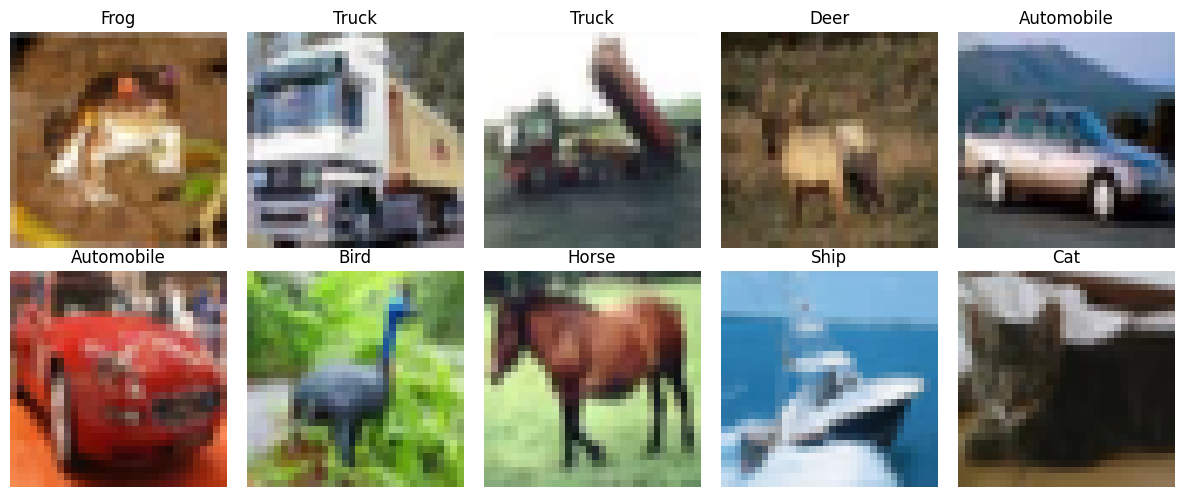

In [5]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("images/sample_images.png", dpi=300, bbox_inches="tight")
plt.show()

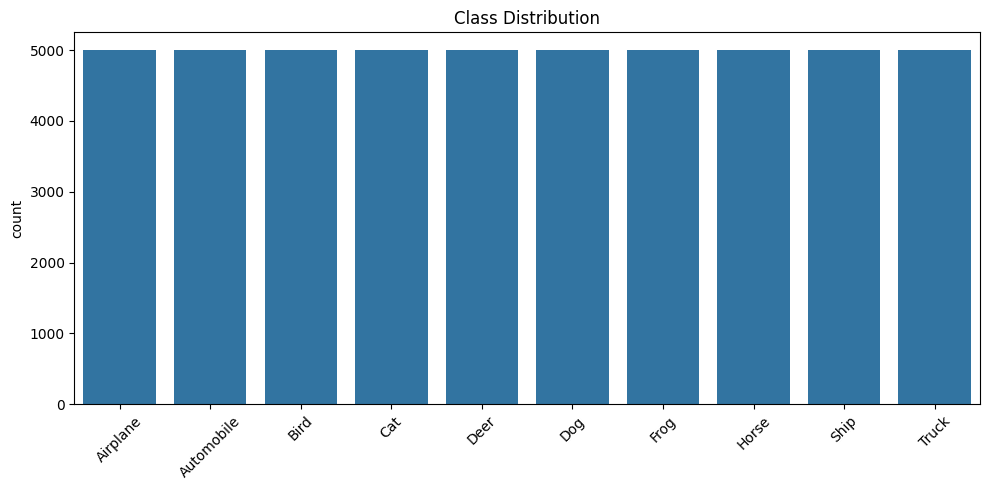

In [6]:
plt.figure(figsize=(10,5))

sns.countplot(x=y_train.flatten())

plt.xticks(range(10), class_names, rotation=45)
plt.title("Class Distribution")

plt.tight_layout()
plt.savefig("images/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
model = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=(1,1),
        padding="same",
        activation="relu",
        input_shape=(32,32,3)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=128,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    ),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 158s 247ms/step - accuracy: 0.3900 - loss: 1.6784 - val_accuracy: 0.5374 - val_loss: 1.2879
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 169s 195ms/step - accuracy: 0.5416 - loss: 1.2874 - val_accuracy: 0.6150 - val_loss: 1.0763
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 183ms/step - accuracy: 0.6059 - loss: 1.1158 - val_accuracy: 0.6563 - val_loss: 0.9712
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 182ms/step - accuracy: 0.6475 - loss: 0.9995 - val_accuracy: 0.6794 - val_loss: 0.9184
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.6769 - loss: 0.9164 - val_accuracy: 0.6787 - val_loss: 0.9297
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 164ms/step - accuracy: 0.7023 - loss: 0.8423 - val_accuracy: 0.7143 - val_loss: 0.8220
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 163ms/step - accuracy: 0.7291 - loss: 0.7724 - val_accuracy: 0.7299 - val_loss: 0.7830
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 172ms/step - accuracy: 0.7501 -

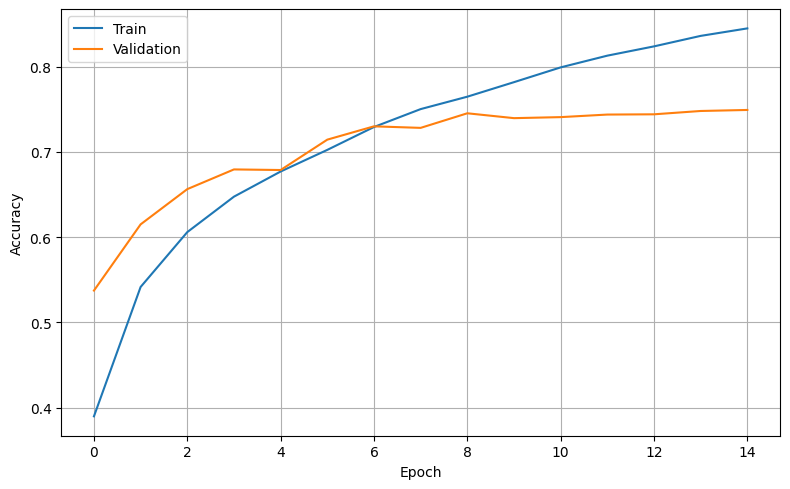

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("images/training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

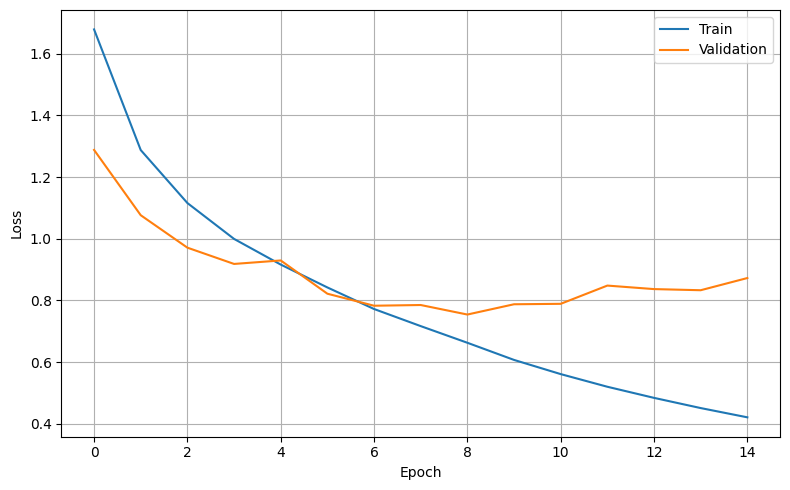

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("images/training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
loss, accuracy = model.evaluate(x_test, y_test_cat)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7410 - loss: 0.8974
Test Loss : 0.8974462151527405
Test Accuracy : 0.7409999966621399


In [13]:
pred = model.predict(x_test)

y_pred = np.argmax(pred, axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


In [14]:
acc = accuracy_score(y_true, y_pred)
pre = precision_score(y_true, y_pred, average="weighted")
rec = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy :", acc)
print("Precision :", pre)
print("Recall :", rec)
print("F1 Score :", f1)

Accuracy : 0.741
Precision : 0.7455032313946364
Recall : 0.741
F1 Score : 0.7416496722000018


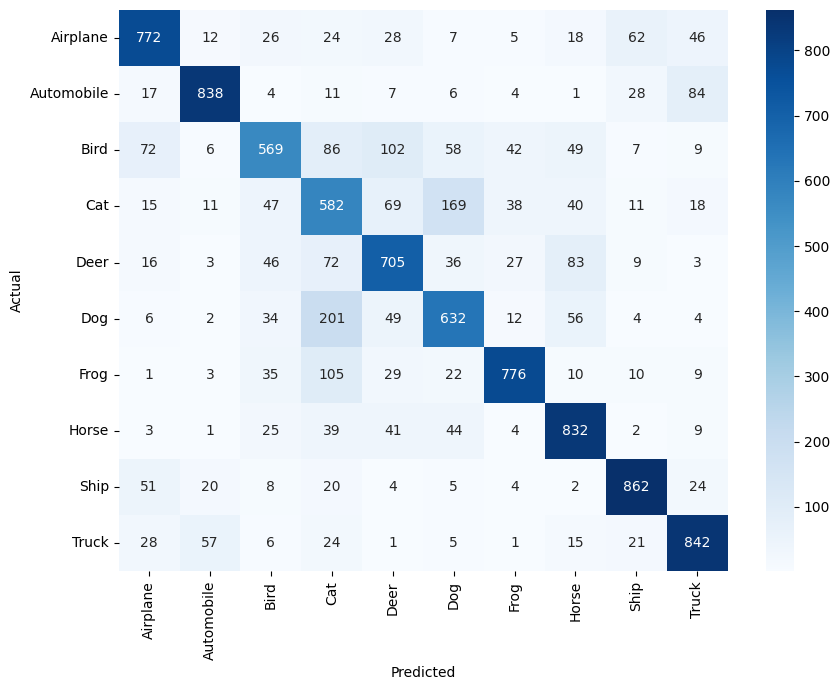

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.79      0.77      0.78      1000
  Automobile       0.88      0.84      0.86      1000
        Bird       0.71      0.57      0.63      1000
         Cat       0.50      0.58      0.54      1000
        Deer       0.68      0.70      0.69      1000
         Dog       0.64      0.63      0.64      1000
        Frog       0.85      0.78      0.81      1000
       Horse       0.75      0.83      0.79      1000
        Ship       0.85      0.86      0.86      1000
       Truck       0.80      0.84      0.82      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


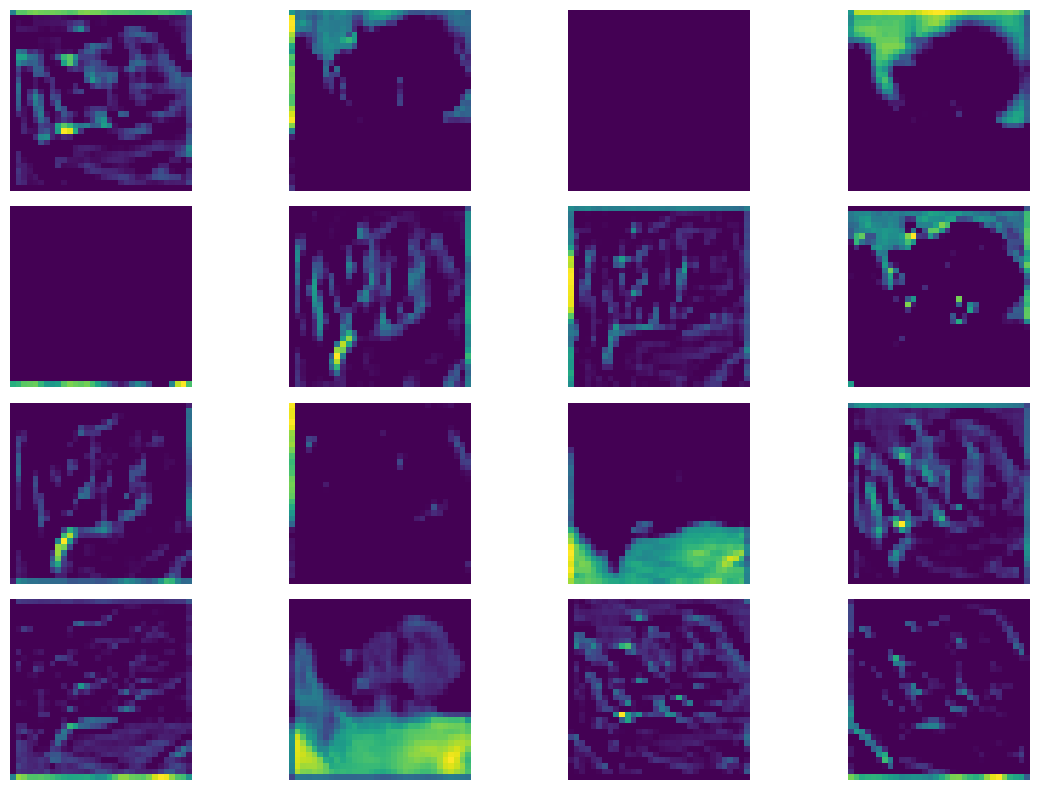

In [19]:
feature_model = Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

feature_maps = feature_model.predict(x_test[:1])

plt.figure(figsize=(12,8))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap="viridis")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "images/feature_maps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

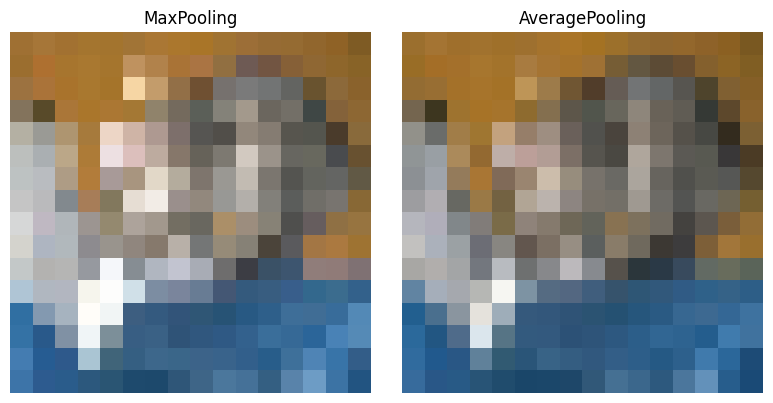

In [20]:
max_pool = MaxPooling2D(pool_size=(2,2))
avg_pool = AveragePooling2D(pool_size=(2,2))

sample = x_test[:1]

max_out = max_pool(sample)
avg_out = avg_pool(sample)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(max_out.numpy()[0])
plt.title("MaxPooling")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(avg_out.numpy()[0])
plt.title("AveragePooling")
plt.axis("off")

plt.tight_layout()
plt.savefig("images/pooling_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
#show hyperparameters

print("Kernel Size : (3,3)")
print("Stride : (1,1)")
print("Padding : same")
print("Filters : 32, 64, 128")
print("Optimizer : Adam")
print("Batch Size : 64")
print("Epochs : 15")

Kernel Size : (3,3)
Stride : (1,1)
Padding : same
Filters : 32, 64, 128
Optimizer : Adam
Batch Size : 64
Epochs : 15


In [22]:
for layer in model.layers:
    if isinstance(layer, Conv2D):
        print(layer.name)
        print("Filters :", layer.filters)
        print("Kernel :", layer.kernel_size)
        print("Trainable Parameters :", layer.count_params())
        print()

conv2d
Filters : 32
Kernel : (3, 3)
Trainable Parameters : 896

conv2d_1
Filters : 64
Kernel : (3, 3)
Trainable Parameters : 18496

conv2d_2
Filters : 128
Kernel : (3, 3)
Trainable Parameters : 73856



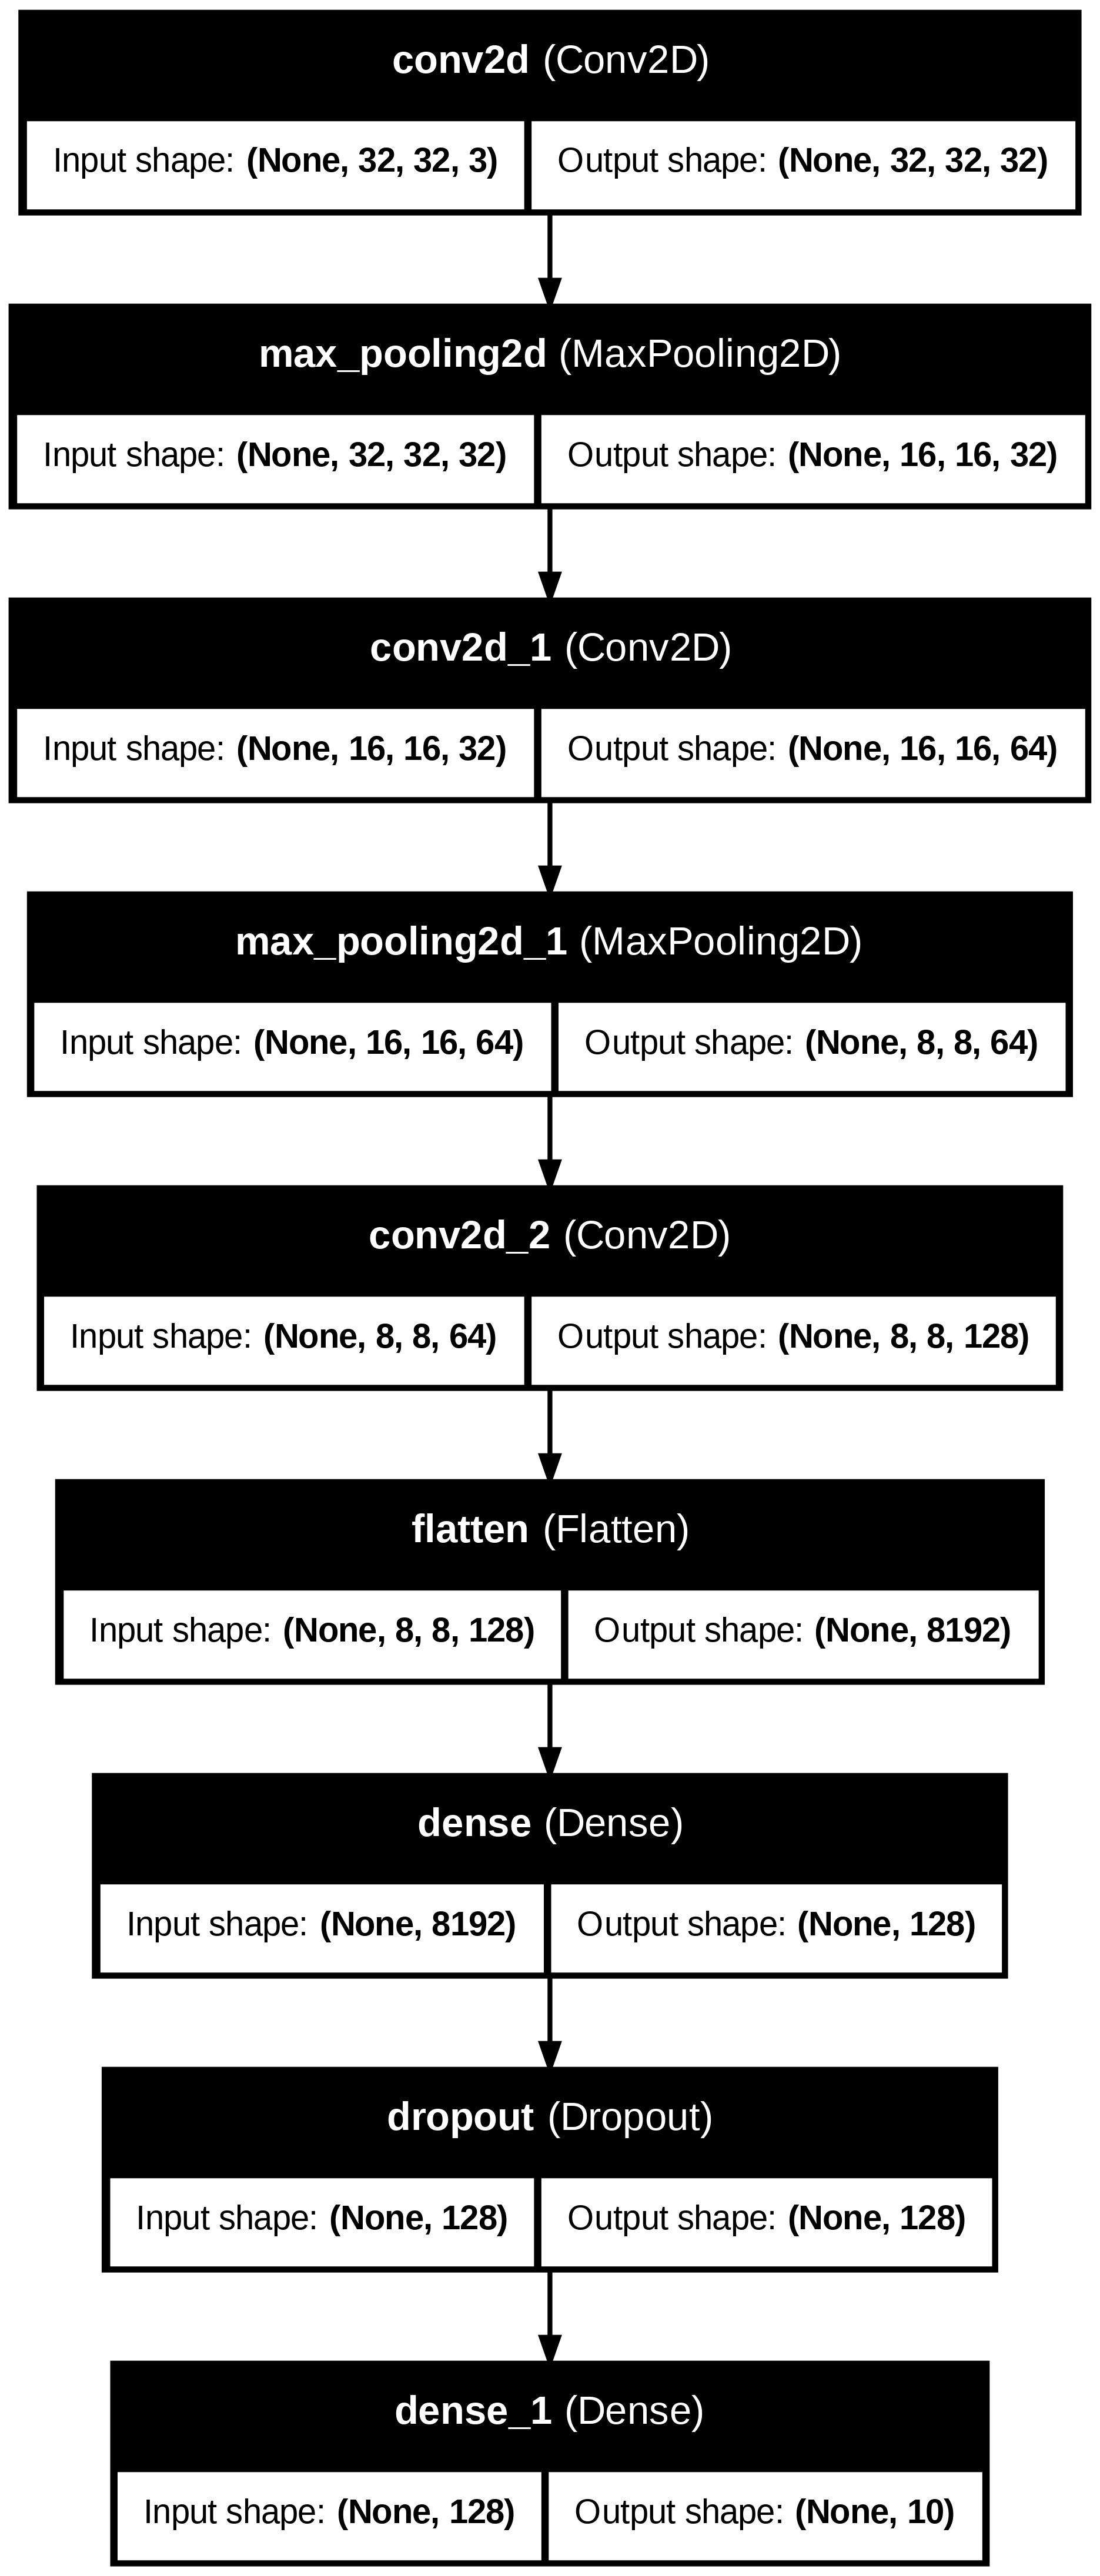

In [24]:
tf.keras.utils.plot_model(
    model,
    to_file="images/cnn_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=300
)

In [25]:
import shutil

shutil.make_archive("cnn_results", "zip", "images")
print("Saved cnn_results.zip")

Saved cnn_results.zip
